<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Análisis exploratorio de datos


Tiempo estimado: **30** minutos
    

## Objetivos

Al finalizar este laboratorio serás capaz de:

* Explorar características o atributos para predecir el precio del automóvil
* Analizar patrones y ejecutar un análisis estadístico descriptivo
* Agrupar los datos según parámetros identificados y crear tablas dinámicas
* Identificar el efecto de los atributos independientes sobre el precio de los automóviles

<h2>Contenido</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#import_data">Importar los datos del módulo</a></li>
    <li><a href="#pattern_visualization">Analizar los patrones de cada característica con visualizaciones</a></li>
    <li><a href="#discriptive_statistics">Análisis estadístico descriptivo</a></li>
    <li><a href="#basic_grouping">Fundamentos de las agrupaciones</a></li>
    <li><a href="#correlation_causation">Correlación y causalidad</a></li>
</ol>

</div>
 
<hr>

<h3>¿Cuáles son las características que más influyen en el precio del automóvil?</h3>

<h2 id="import_data">1. Importar los datos del módulo 2</h2>

<h4>Configuración</h4>

Importa las bibliotecas: 

In [ ]:
# instalar una versión específica de las bibliotecas usadas en el laboratorio
#! mamba install pandas==1.3.3
#! mamba install numpy=1.21.2
#! mamba install scipy=1.7.1-y
#!  mamba install seaborn=0.9.0-y

In [1]:
import pandas as pd
import numpy as np

Carga los datos y guárdalos en el dataframe `df`:

Este conjunto de datos estaba alojado en IBM Cloud object. Haz clic <a href="https://cocl.us/DA101EN_object_storage">AQUÍ</a> para obtener almacenamiento gratuito.

In [2]:
path='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv'
df = pd.read_csv(path)
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<h2 id="pattern_visualization">2. Analizar los patrones de cada característica con visualizaciones</h2>

Para instalar Seaborn usamos pip, el gestor de paquetes de Python.

Importa los paquetes de visualización "Matplotlib" y "Seaborn". No olvides "%matplotlib inline" para graficar en un cuaderno de Jupyter.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

<h4>¿Cómo elegir el método de visualización adecuado?</h4>
<p>Al visualizar variables individuales es importante entender primero con qué tipo de variable estás trabajando. Eso nos ayuda a encontrar el método de visualización adecuado para esa variable.</p>

In [4]:
# listar los tipos de datos de cada columna
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Pregunta #1:</h3>

<b>¿Cuál es el tipo de dato de la columna "peak-rpm"? </b>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar 

<details><summary>Haz clic aquí para ver la solución</summary>

```python    
float64
```

</details>

Por ejemplo, podemos calcular la correlación entre variables de tipo "int64" o "float64" con el método "corr":

In [28]:
df.corr(numeric_only=True)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


Los elementos de la diagonal siempre valen uno; al final del cuaderno estudiaremos la correlación de Pearson con más detalle.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3> Pregunta #2: </h3>

<p>Encuentra la correlación entre las siguientes columnas: bore, stroke, compression-ratio y horsepower.</p>
<p>Pista: si quieres seleccionar esas columnas, usa la sintaxis: df[['bore','stroke','compression-ratio','horsepower']]</p>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar 

<details><summary>Haz clic aquí para ver la solución</summary>

```python
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()
```

</details>

<h2>Variables numéricas continuas:</h2> 

<p>Las variables numéricas continuas son variables que pueden tomar cualquier valor dentro de un rango. Pueden ser de tipo "int64" o "float64". Una excelente forma de visualizarlas es con diagramas de dispersión y su recta ajustada.</p>

<p>Para empezar a entender la relación (lineal) entre una variable individual y el precio podemos usar "regplot", que dibuja el diagrama de dispersión junto con la recta de regresión ajustada a los datos. Esto también será útil más adelante para visualizar el ajuste del modelo de regresión lineal simple. </p>

  Veamos varios ejemplos de distintas relaciones lineales:

<h3>Relación lineal positiva</h4>

Busquemos el diagrama de dispersión de "engine-size" y "price".

(0.0, 53608.94108287327)

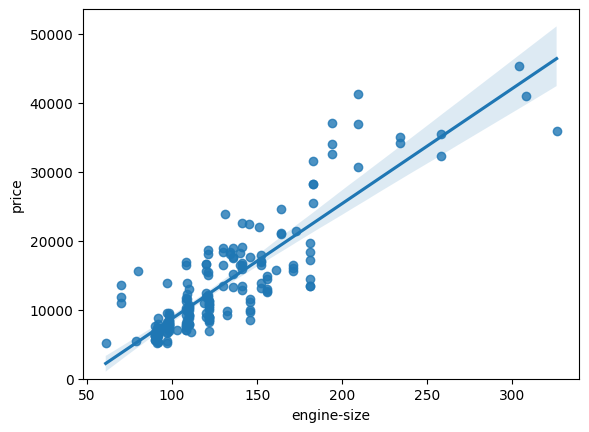

In [6]:
# el tamaño del motor como posible variable predictora del precio
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)

<p>A medida que sube el tamaño del motor, sube el precio: esto indica una correlación positiva directa entre las dos variables. El tamaño del motor parece un buen predictor del precio, ya que la recta de regresión es casi una diagonal perfecta.</p>

  Podemos examinar la correlación entre 'engine-size' y 'price' y ver que es aproximadamente 0.87.

In [7]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


El rendimiento en carretera (highway mpg) es una posible variable predictora del precio. Busquemos el diagrama de dispersión de "highway-mpg" y "price".

<Axes: xlabel='highway-mpg', ylabel='price'>

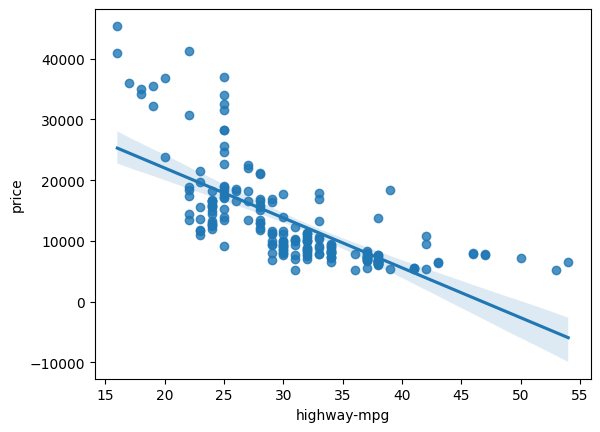

In [8]:
sns.regplot(x="highway-mpg", y="price", data=df)

<p>A medida que sube highway-mpg, baja el precio: esto indica una relación inversa o negativa entre las dos variables. El rendimiento en carretera podría ser un predictor del precio.</p>

Podemos examinar la correlación entre 'highway-mpg' y 'price' y ver que es aproximadamente -0.704.

In [9]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


<h3>Relación lineal débil</h3>

Veamos si "peak-rpm" es una variable predictora de "price".

<Axes: xlabel='peak-rpm', ylabel='price'>

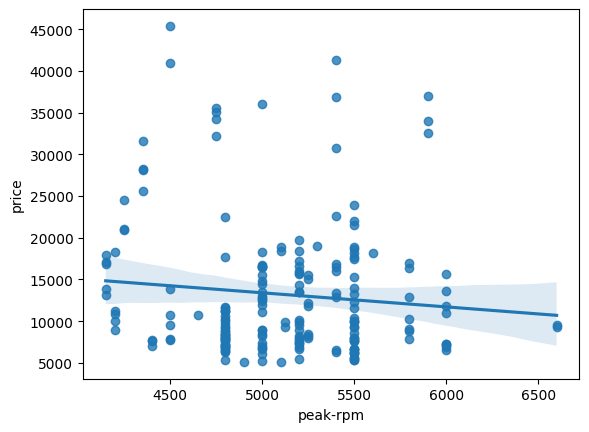

In [10]:
sns.regplot(x="peak-rpm", y="price", data=df)

<p>Peak rpm no parece un buen predictor del precio en absoluto, porque la recta de regresión es casi horizontal. Además, los puntos están muy dispersos y lejos de la recta ajustada, lo que muestra mucha variabilidad. Por lo tanto, no es una variable confiable.</p>

Podemos examinar la correlación entre 'peak-rpm' y 'price' y ver que es aproximadamente -0.101616.

In [11]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


  <div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Pregunta 3 a): </h1>

<p>Encuentra la correlación entre x="stroke" y y="price".</p>
<p>Pista: si quieres seleccionar esas columnas, usa la sintaxis: df[["stroke","price"]].  </p>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar 

<details><summary>Haz clic aquí para ver la solución</summary>

```python

# La correlación es 0.0823, los elementos fuera de la diagonal de la tabla.

df[["stroke","price"]].corr()

```

</details>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta 3 b):</h1>

<p>Con los resultados de correlación entre "price" y "stroke", ¿esperas una relación lineal?</p> 
<p>Verifica tus resultados con la función "regplot()".</p>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar 

<details><summary>Haz clic aquí para ver la solución</summary>

```python

# La correlación entre la variable 'stroke' y 'price' es débil, así que la regresión no funcionará bien. Podemos comprobarlo con "regplot".

# código: 
sns.regplot(x="stroke", y="price", data=df)

```

</details>

<h3>Variables categóricas</h3>

<p>Son variables que describen una 'característica' de una unidad de datos y se eligen de un grupo pequeño de categorías. Las variables categóricas pueden ser de tipo "object" o "int64". Una buena forma de visualizarlas es con diagramas de caja.</p>

Veamos la relación entre "body-style" y "price".

<Axes: xlabel='body-style', ylabel='price'>

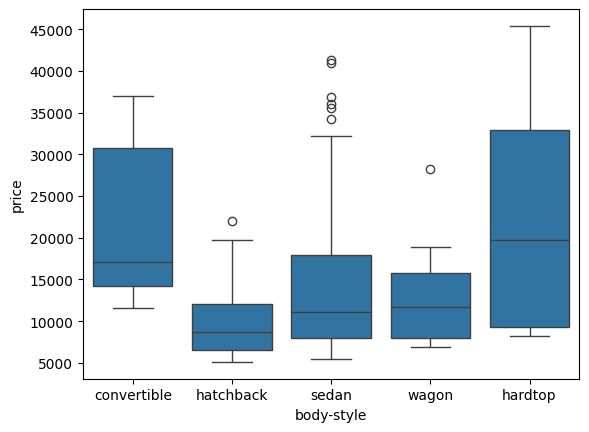

In [12]:
sns.boxplot(x="body-style", y="price", data=df)

<p>Vemos que las distribuciones del precio entre las distintas categorías de body-style se superponen bastante, así que body-style no sería un buen predictor del precio. Examinemos ahora "engine-location" y "price":</p>

<Axes: xlabel='engine-location', ylabel='price'>

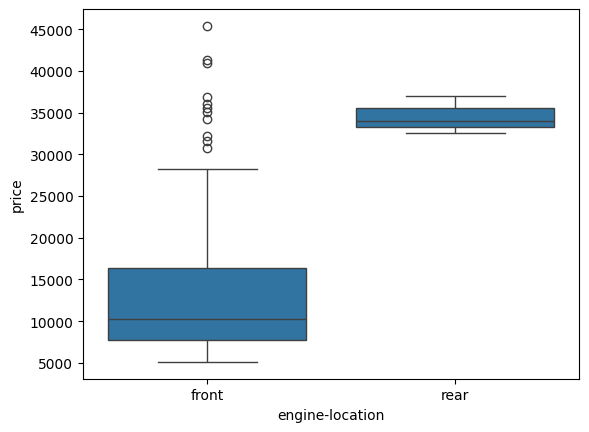

In [13]:
sns.boxplot(x="engine-location", y="price", data=df)

<p>Aquí vemos que la distribución del precio entre las dos categorías de engine-location, delantero y trasero, es lo bastante distinta como para considerar engine-location un posible buen predictor del precio.</p>

  Examinemos "drive-wheels" y "price".

<Axes: xlabel='drive-wheels', ylabel='price'>

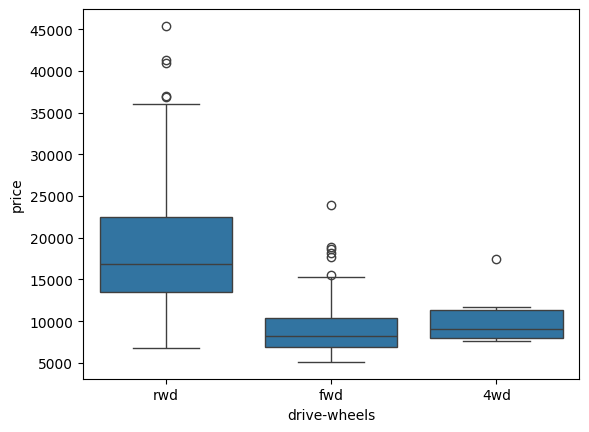

In [14]:
# drive-wheels
sns.boxplot(x="drive-wheels", y="price", data=df)

<p>Aquí vemos que la distribución del precio entre las distintas categorías de drive-wheels es diferente. Por lo tanto, drive-wheels podría ser un predictor del precio.</p>

<h2 id="discriptive_statistics">3. Análisis estadístico descriptivo</h2>

<p>Primero veamos las variables con un método de descripción.</p>

<p>La función <b>describe</b> calcula automáticamente estadísticas básicas de todas las variables continuas. Los valores NaN se omiten automáticamente en esas estadísticas.</p>

Mostrará:
<ul>
    <li>el conteo de esa variable</li>
    <li>la media</li>
    <li>la desviación estándar (std)</li> 
    <li>el valor mínimo</li>
    <li>el IQR (rango intercuartílico: 25%, 50% y 75%)</li>
    <li>el valor máximo</li>
<ul>

  Podemos aplicar el método "describe" así:

In [15]:
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


  La configuración por defecto de "describe" omite las variables de tipo object. Podemos aplicarlo a las variables de tipo 'object' así:

In [16]:
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


<h3>Conteo de valores</h3>

<p>El conteo de valores es una buena forma de entender cuántas unidades hay de cada característica o variable. Podemos aplicar el método "value_counts" sobre la columna "drive-wheels". No olvides que "value_counts" solo funciona sobre series de pandas, no sobre dataframes. Por eso se usan unos corchetes <code>df['drive-wheels']</code> y no dos <code>df[['drive-wheels']]</code>.</p>

In [17]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

Podemos convertir la serie en un dataframe así:

In [18]:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


Repitamos los pasos anteriores, pero guardando los resultados en el dataframe "drive_wheels_counts" y renombrando la columna 'drive-wheels' como 'value_counts'.

In [19]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'}, inplace=True)
drive_wheels_counts

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


  Ahora renombremos el índice como 'drive-wheels':

In [20]:
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


Podemos repetir el proceso anterior para la variable 'engine-location'.

In [21]:
# engine-location as variable
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


<p>Después de revisar el conteo de valores de la ubicación del motor, vemos que no sería una buena variable predictora del precio. Esto se debe a que solo hay tres automóviles con motor trasero y 198 con motor delantero, así que el resultado está sesgado. Por lo tanto, no podemos sacar conclusiones sobre la ubicación del motor.</p>

<h2 id="basic_grouping">4. Fundamentos de las agrupaciones</h2>

<p>El método "groupby" agrupa los datos por distintas categorías. Los datos se agrupan según una o varias variables y el análisis se hace sobre cada grupo por separado.</p>

<p>Por ejemplo, agrupemos por la variable "drive-wheels". Vemos que hay 3 categorías distintas de tracción.</p>

In [22]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

<p>Si queremos saber, en promedio, qué tipo de tracción es el más costoso, podemos agrupar por "drive-wheels" y luego promediar.</p>

<p>Podemos seleccionar las columnas 'drive-wheels', 'body-style' y 'price', y asignarlas a la variable "df_group_one".</p>

In [25]:
df_group_one = df[['drive-wheels','body-style','price']]

Luego podemos calcular el precio promedio de cada una de las categorías.

In [30]:
# resultados de la agrupación
df_group_one = df_group_one.groupby(['drive-wheels'],as_index=False).mean(numeric_only=True)
df_group_one

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


<p>Según nuestros datos, los vehículos de tracción trasera son, en promedio, los más costosos, mientras que los de tracción en las cuatro ruedas y delantera tienen un precio parecido.</p>

<p>También puedes agrupar por varias variables. Por ejemplo, agrupemos por 'drive-wheels' y 'body-style' a la vez. Esto agrupa el dataframe por cada combinación única de 'drive-wheels' y 'body-style'. Podemos guardar los resultados en la variable 'grouped_test1'.</p>

In [31]:
# resultados de la agrupación
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean(numeric_only=True)
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


<p>Estos datos agrupados se visualizan mucho mejor en una tabla dinámica. Una tabla dinámica es como una hoja de Excel, con una variable en las columnas y otra en las filas. Podemos convertir el dataframe en una tabla dinámica con el método "pivot".</p>

<p>En este caso dejaremos la variable drive-wheels como filas de la tabla y llevaremos body-style a las columnas:</p>

In [32]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels',columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

<p>A menudo no tendremos datos para algunas celdas de la tabla dinámica. Podemos rellenar esas celdas vacías con el valor 0, aunque también podría usarse cualquier otro valor. Cabe mencionar que los datos faltantes son un tema bastante complejo, con un curso completo por sí solos.</p>

In [ ]:
grouped_pivot = grouped_pivot.fillna(0) #fill missing values with 0
grouped_pivot

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Pregunta 4:</h1>

<p>Usa la función "groupby" para hallar el "price" promedio de los automóviles según "body-style".</p>
</div>

In [ ]:
# Escribe tu código a continuación y presiona Shift+Enter para ejecutar 

<details><summary>Haz clic aquí para ver la solución</summary>

```python
# resultados de la agrupación
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'],as_index= False).mean(numeric_only=True)
grouped_test_bodystyle

```

</details>

Si no importaste "pyplot", hagámoslo de nuevo. 

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline 

<h4>Variables: tracción y estilo de carrocería frente al precio</h4>

Usemos un mapa de calor para visualizar la relación entre el estilo de carrocería y el precio.

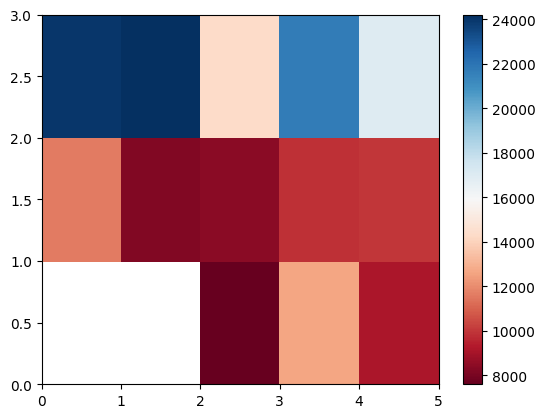

In [34]:
# usar los resultados agrupados
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

<p>El mapa de calor representa la variable objetivo (price) con un color proporcional a su valor, frente a las variables 'drive-wheel' y 'body-style' en el eje vertical y horizontal, respectivamente. Así podemos ver cómo se relaciona el precio con 'drive-wheel' y 'body-style'.</p>

<p>Las etiquetas por defecto no aportan información útil. Cambiémoslas:</p>

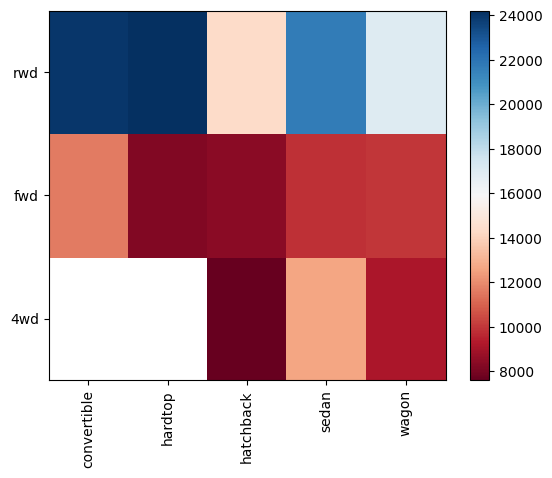

In [35]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

# nombres de las etiquetas
row_labels = grouped_pivot.columns.levels[1]
col_labels = grouped_pivot.index

# mover las marcas y las etiquetas al centro
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

# insertar las etiquetas
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

# girar la etiqueta si es muy larga
plt.xticks(rotation=90)

fig.colorbar(im)
plt.show()

<p>La visualización es muy importante en ciencia de datos, y los paquetes de visualización de Python ofrecen gran libertad. Profundizaremos más en un curso aparte de visualizaciones con Python.</p>

<p>La pregunta principal que queremos responder en este módulo es: "¿cuáles son las características que más influyen en el precio del automóvil?".</p>

<p>Para medir mejor las características importantes, observamos la correlación de esas variables con el precio del automóvil. En otras palabras: ¿qué tanto depende el precio de esa variable?</p>

<h2 id="correlation_causation">5. Correlación y causalidad</h2>

<p><b>Correlación</b>: medida del grado de interdependencia entre variables.</p>

<p><b>Causalidad</b>: la relación de causa y efecto entre dos variables.</p>

<p>Es importante conocer la diferencia entre ambas. Correlación no implica causalidad. Determinar la correlación es mucho más sencillo que determinar la causalidad, porque esta última puede requerir experimentación independiente.</p>

<p><b>Correlación de Pearson</b></p>
<p>La correlación de Pearson mide la dependencia lineal entre dos variables X y Y.</p>
<p>El coeficiente resultante es un valor entre -1 y 1, ambos incluidos, donde:</p>
<ul>
    <li><b>1</b>: correlación lineal positiva perfecta.</li>
    <li><b>0</b>: sin correlación lineal; lo más probable es que las dos variables no se afecten entre sí.</li>
    <li><b>-1</b>: correlación lineal negativa perfecta.</li>
</ul>

<p>La correlación de Pearson es el método por defecto de la función "corr". Como antes, podemos calcularla sobre las variables de tipo 'int64' o 'float64'.</p>

In [36]:
df.corr(numeric_only=True)

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


A veces queremos saber si la correlación estimada es significativa. 

<b>Valor p</b>
<p>¿Qué es el valor p? Es el valor de probabilidad de que la correlación entre las dos variables sea estadísticamente significativa. Normalmente se elige un nivel de significancia de 0.05, lo que significa que tenemos un 95% de confianza en que la correlación entre las variables es significativa.</p>

Por convención, cuando el valor p:
<ul>
    <li>es $<$ 0.001: hay evidencia fuerte de que la correlación es significativa.</li>
    <li>es $<$ 0.05: hay evidencia moderada de que la correlación es significativa.</li>
    <li>es $<$ 0.1: hay evidencia débil de que la correlación es significativa.</li>
    <li>es $>$ 0.1: no hay evidencia de que la correlación sea significativa.</li>
</ul>

  Podemos obtener esta información con el módulo "stats" de la biblioteca "scipy".

In [37]:
from scipy import stats

<h3>Distancia entre ejes (wheel-base) frente al precio</h3>

Calculemos el coeficiente de correlación de Pearson y el valor p de 'wheel-base' y 'price'. 

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P =", p_value)  

<h4>Conclusión:</h4>
<p>Como el valor p es $<$ 0.001, la correlación entre wheel-base y price es estadísticamente significativa, aunque la relación lineal no es muy fuerte (~0.585).</p>

<h3>Potencia (horsepower) frente al precio</h3>

  Calculemos el coeficiente de correlación de Pearson y el valor p de 'horsepower' y 'price'.

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P = ", p_value)  

<h4>Conclusión:</h4>

<p>Como el valor p es $<$ 0.001, la correlación entre horsepower y price es estadísticamente significativa y la relación lineal es bastante fuerte (~0.809, cerca de 1).</p>

<h3>Longitud (length) frente al precio</h3>

Calculemos el coeficiente de correlación de Pearson y el valor p de 'length' y 'price'.

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P = ", p_value)  

<h4>Conclusión:</h4>
<p>Como el valor p es $<$ 0.001, la correlación entre length y price es estadísticamente significativa y la relación lineal es moderadamente fuerte (~0.691).</p>

<h3>Ancho (width) frente al precio</h3>

  Calculemos el coeficiente de correlación de Pearson y el valor p de 'width' y 'price':

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P =", p_value ) 

#### Conclusión:

Como el valor p es < 0.001, la correlación entre width y price es estadísticamente significativa y la relación lineal es bastante fuerte (~0.751).

### Peso en vacío (curb-weight) frente al precio

  Calculemos el coeficiente de correlación de Pearson y el valor p de 'curb-weight' y 'price':

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print( "El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P = ", p_value)  

<h4>Conclusión:</h4>
<p>Como el valor p es $<$ 0.001, la correlación entre curb-weight y price es estadísticamente significativa y la relación lineal es bastante fuerte (~0.834).</p>

<h3>Tamaño del motor (engine-size) frente al precio</h3>

Calculemos el coeficiente de correlación de Pearson y el valor p de 'engine-size' y 'price':

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['engine-size'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P =", p_value) 

<h4>Conclusión:</h4>

<p>Como el valor p es $<$ 0.001, la correlación entre engine-size y price es estadísticamente significativa y la relación lineal es muy fuerte (~0.872).</p>

<h3>Diámetro del cilindro (bore) frente al precio</h3>

  Calculemos el coeficiente de correlación de Pearson y el valor p de 'bore' y 'price':

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['bore'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P =  ", p_value ) 

<h4>Conclusión:</h4>
<p>Como el valor p es $<$ 0.001, la correlación entre bore y price es estadísticamente significativa, pero la relación lineal solo es moderada (~0.521).</p>

  Podemos repetir el proceso para 'city-mpg' y 'highway-mpg':

<h3>Rendimiento en ciudad (city-mpg) frente al precio</h3>

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['city-mpg'], df['price'])
print("El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P = ", p_value)  

<h4>Conclusión:</h4>
<p>Como el valor p es $<$ 0.001, la correlación entre city-mpg y price es estadísticamente significativa, y el coeficiente de aproximadamente -0.687 muestra que la relación es negativa y moderadamente fuerte.</p>

<h3>Rendimiento en carretera (highway-mpg) frente al precio</h3>

In [ ]:
pearson_coef, p_value = stats.pearsonr(df['highway-mpg'], df['price'])
print( "El coeficiente de correlación de Pearson es", pearson_coef, " con un valor p de P = ", p_value ) 

#### Conclusión:
Como el valor p es < 0.001, la correlación entre highway-mpg y price es estadísticamente significativa, y el coeficiente de aproximadamente -0.705 muestra que la relación es negativa y moderadamente fuerte.

<h3>Conclusión: variables importantes</h3>

<p>Ahora tenemos una mejor idea de cómo son nuestros datos y de qué variables conviene tener en cuenta al predecir el precio del automóvil. Las hemos reducido a las siguientes:</p>

Variables numéricas continuas:
<ul>
    <li>Length (longitud)</li>
    <li>Width (ancho)</li>
    <li>Curb-weight (peso en vacío)</li>
    <li>Engine-size (tamaño del motor)</li>
    <li>Horsepower (potencia)</li>
    <li>City-mpg (rendimiento en ciudad)</li>
    <li>Highway-mpg (rendimiento en carretera)</li>
    <li>Wheel-base (distancia entre ejes)</li>
    <li>Bore (diámetro del cilindro)</li>
</ul>
    
Variables categóricas:
<ul>
    <li>Drive-wheels (tracción)</li>
</ul>

<p>Ahora que pasamos a construir modelos de aprendizaje automático para automatizar el análisis, alimentar el modelo con variables que afectan de forma significativa a nuestra variable objetivo mejorará su capacidad de predicción.</p>

### ¡Gracias por completar este laboratorio!


## Autor

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Otros colaboradores

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href="https://www.coursera.org/instructor/~129186572/" target="_blank" >Abhishek Gagneja </a>

## Registro de cambios


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.2 | Abhishek Gagneja | Updated instructions |
| 2020-10-30  | 2.1  | Lakshmi |  changed URL of csv  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |



<hr>

## <h3 align="center"> © IBM Corporation 2023. Todos los derechos reservados. <h3/>
